# **✅ Task 9: Random Forest – Credit Card Fraud Detection:**

## **Import some required Libraries:**

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score

## **Load dataset and check fraud vs non-fraud counts to understand imbalance:**

In [3]:
df = pd.read_csv('Datasets/creditcard.csv')

In [9]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [12]:
df['Class'].unique()

array([0, 1])

In [11]:
df['Class'].value_counts() # There is huge imbalance of fraud vs. non-fraud

,count
Class,
0,284315
1,492


## **Separate features and target column and remove non-useful identifiers:**

In [18]:
df.shape

(284807, 31)

In [16]:
filtered_dataset = df.copy()

In [17]:
filtered_dataset.drop(columns=['Time'],inplace=True)

In [19]:
filtered_dataset.shape

(284807, 30)

In [20]:
X = filtered_dataset.drop(columns=['Class'])
y = filtered_dataset['Class']

## **Split dataset using stratified sampling so fraud ratio stays similar in train and test:**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)

## **Train a baseline model like Logistic Regression:**

In [24]:
lR = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

In [25]:
lR.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [26]:
y_pred = lR.predict(X_test)

## **Predict and evaluate using precision, recall, F1-score instead of accuracy for LR:**

In [27]:
accuracy_score(y_test,y_pred)

0.9745268775675011

In [34]:
precision_score(y_test,y_pred) ## precision score is very very lesss!!

0.05870841487279843

In [49]:
recall_score(y_test,y_pred)

0.9183673469387755

In [50]:
f1_score(y_test,y_pred)

0.11036174126302882

In [30]:
confusion_matrix(y_test,y_pred)

array([[55421,  1443],
       [    8,    90]])

## **Train Random Forest model with parameters like n_estimators=100:**

In [35]:
rfc = RandomForestClassifier(random_state=42,n_estimators=100,class_weight='balanced',n_jobs=-1)

In [36]:
rfc.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [37]:
y_pred_tree = rfc.predict(X_test)

## **Predict and evaluate using precision, recall, F1-score instead of accuracy for RFC:**

In [38]:
precision_score(y_test,y_pred_tree) # very high precision

0.961038961038961

In [39]:
accuracy_score(y_test,y_pred_tree)

0.9995259997893332

In [51]:
recall_score(y_test,y_pred_tree)

0.7551020408163265

In [53]:
f1_score(y_test,y_pred_tree)

0.8457142857142858

In [54]:
confusion_matrix(y_test,y_pred_tree)

array([[56861,     3],
       [   24,    74]])

## **Plot feature importances to identify key fraud indicators:**

In [42]:
# Get importance values from model
importances = rfc.feature_importances_

In [43]:
# Get feature names
features = X_train.columns

In [44]:
# Put into a table
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
})

In [45]:
# Sort by importance (highest first)
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

In [46]:
# Show top 10 important features
print(feature_importance_df.head(10))

   Feature  Importance
3       V4    0.148430
9      V10    0.147753
13     V14    0.138963
11     V12    0.091493
10     V11    0.087472
16     V17    0.060587
6       V7    0.046484
2       V3    0.045847
15     V16    0.037490
1       V2    0.017323


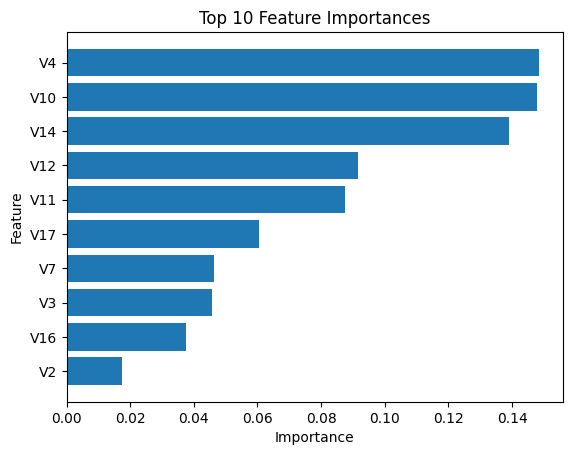

In [47]:
plt.barh(feature_importance_df["Feature"][:10],
         feature_importance_df["Importance"][:10])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.savefig('top-10-features.png')
plt.show()

## **Comparision of Random Forest and Logistic Regression Model:**

The Logistic Regression model shows high accuracy (97.45%), but this is not very meaningful because the dataset is highly imbalanced. Although it has a very high recall (91.84%), meaning it catches most fraud cases, its precision is extremely low (5.87%), which means most transactions it marks as fraud are actually normal. This leads to a very low F1-score (0.11), showing poor overall performance.
On the other hand, the Random Forest model performs much better. It has a very high accuracy (99.95%) and also a very high precision (96.10%), meaning almost all transactions it flags as fraud are truly fraud. Its recall (75.51%) is slightly lower than Logistic Regression but still good, and its F1-score (0.85) shows a strong balance between catching fraud and avoiding false alarms. Overall, Random Forest is clearly the better model for fraud detection.

## **Saving the Model for Reuse:**

In [55]:
import joblib

In [56]:
joblib.dump(rfc, "best_fraud_model.pkl")
print("Model saved successfully!")

Model saved successfully!
